In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Accuracy: 0.7988826815642458


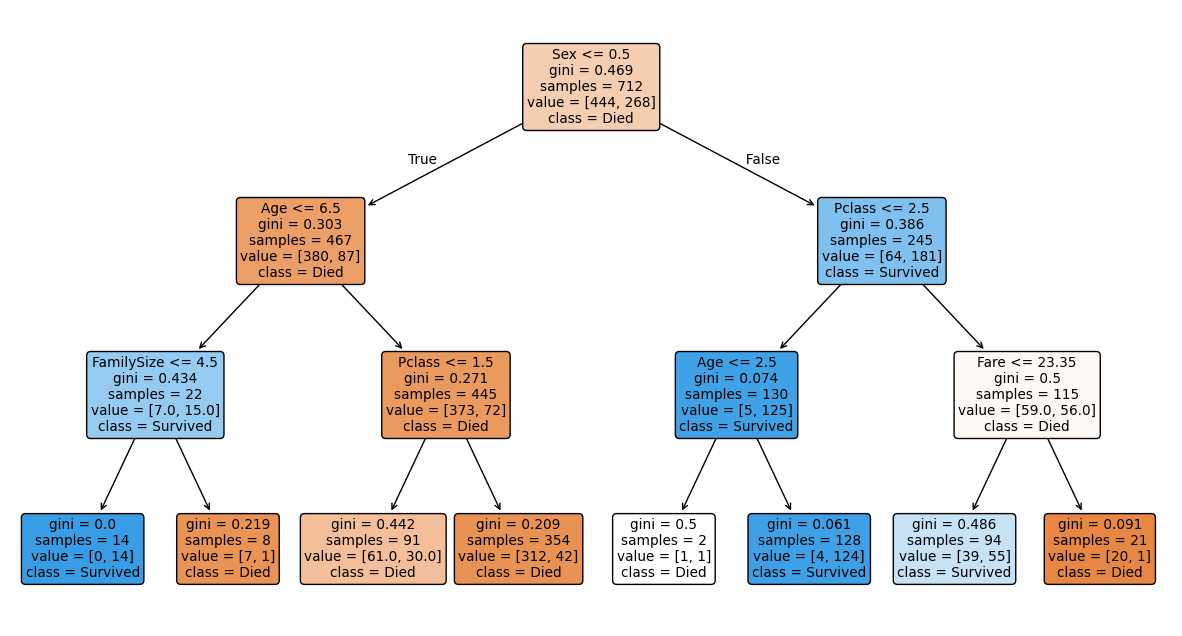

In [5]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd

# Load Titanic
df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')

# Clean
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# Features
features = ["Pclass", "Sex", "Age", "Fare", "FamilySize"]
X = df[features]
y = df["Survived"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train Decision Tree
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

# Evaluate
predictions = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, predictions))

# Visualize the tree
plt.figure(figsize=(15,8))
plot_tree(model, feature_names=features, 
          class_names=["Died", "Survived"],
          filled=True, rounded=True)
plt.show()